# 🧠 Parkinson's Disease Detection: ML for Neurological Screening

**Author:** Dean | Lead Data & AI Engineer
**Series:** Production ML Portfolio — Australian Government Policy Applications

## Government Context
- **Dept of Health** — Neurological conditions strategy, aged care interface
- **AIHW** — Neurological disease surveillance, disability burden
- **NDIS** — Parkinson's support packages, functional capacity assessment
- **TGA** — Medical device regulation for diagnostic tools
- **Parkinson's Australia** — Awareness, research funding advocacy

Dataset: UCI Parkinson's — 195 samples, 22 voice features, binary (Healthy/Parkinson's). All numeric.

---

## 1. Data Loading

In [1]:
import os,warnings,time,numpy as np,pandas as pd,matplotlib.pyplot as plt,seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score,f1_score,classification_report,confusion_matrix,roc_auc_score,precision_score,recall_score,brier_score_loss
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
warnings.filterwarnings('ignore');plt.style.use('seaborn-v0_8-whitegrid')
print("READY")

READY


In [2]:
dp=None
for r,d,files in os.walk('/kaggle/input'):
    for f in files:
        fp=os.path.join(r,f);print(f"  {fp}")
        if f.endswith('.csv') and dp is None: dp=fp
if dp is None: raise FileNotFoundError("No CSV")
df=pd.read_csv(dp,encoding='latin-1')
print(f"Loaded: {df.shape[0]:,} x {df.shape[1]}")
for i,col in enumerate(df.columns):
    print(f"  {i:2d}. {col:25s} | {str(df[col].dtype):8s} | uniq={df[col].nunique():5d}")
df.head()

  /kaggle/input/datasets/imkrkannan/parkinsons/datasets_410614_786211_parkinsons.csv
Loaded: 195 x 24
   0. name                      | object   | uniq=  195
   1. MDVP:Fo(Hz)               | float64  | uniq=  195
   2. MDVP:Fhi(Hz)              | float64  | uniq=  195
   3. MDVP:Flo(Hz)              | float64  | uniq=  195
   4. MDVP:Jitter(%)            | float64  | uniq=  173
   5. MDVP:Jitter(Abs)          | float64  | uniq=   19
   6. MDVP:RAP                  | float64  | uniq=  155
   7. MDVP:PPQ                  | float64  | uniq=  165
   8. Jitter:DDP                | float64  | uniq=  180
   9. MDVP:Shimmer              | float64  | uniq=  188
  10. MDVP:Shimmer(dB)          | float64  | uniq=  149
  11. Shimmer:APQ3              | float64  | uniq=  184
  12. Shimmer:APQ5              | float64  | uniq=  189
  13. MDVP:APQ                  | float64  | uniq=  189
  14. Shimmer:DDA               | float64  | uniq=  189
  15. NHR                       | float64  | uniq=  185
  

,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,phon_R01_S01_1,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,...,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,phon_R01_S01_2,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,...,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,phon_R01_S01_3,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,...,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,phon_R01_S01_4,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,...,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,phon_R01_S01_5,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,...,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335


## 2. Target

In [3]:
tc=None
for x in ['status','Status','target','Target','class','Class','Parkinson','parkinsons']:
    if x in df.columns: tc=x;break
if tc is None:
    for x in df.columns:
        if df[x].nunique()==2 and df[x].dtype in ['int64','float64'] and x.lower() not in ['id','name']: tc=x;break
if tc is None: tc=df.columns[-1]
df=df.dropna(subset=[tc]);df[tc]=df[tc].astype(int)
print(f"Target: '{tc}'");print(df[tc].value_counts().sort_index())
assert df[tc].nunique()>=2

Target: 'status'
status
0     48
1    147
Name: count, dtype: int64


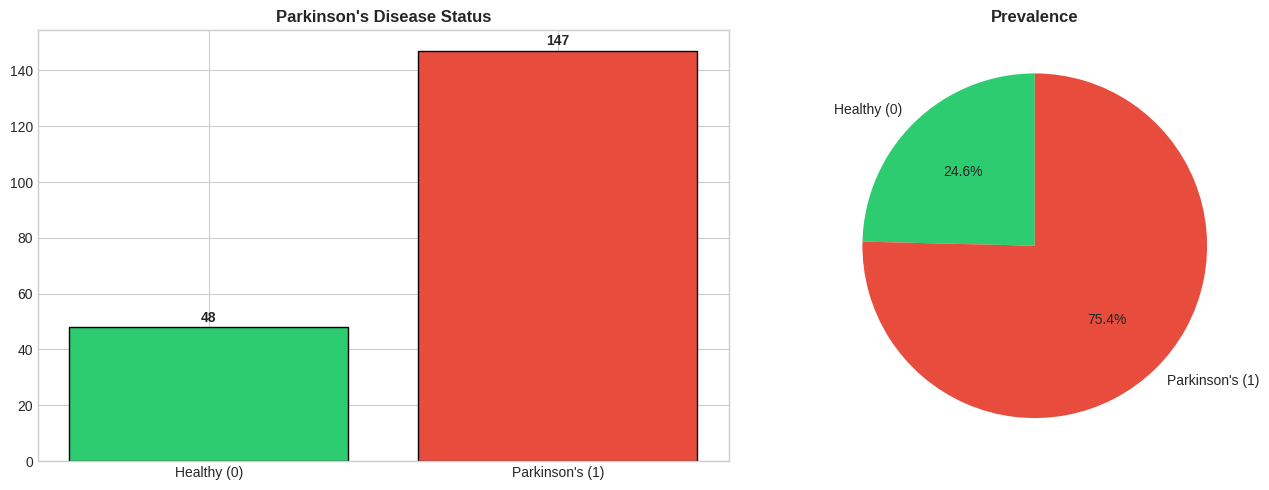

AU: ~100,000 Australians live with Parkinson's. 2nd most common neurodegenerative disease.


In [4]:
fig,axes=plt.subplots(1,2,figsize=(14,5))
vc=df[tc].value_counts().sort_index();labels=['Healthy (0)',"Parkinson's (1)"];colors=['#2ecc71','#e74c3c']
axes[0].bar(range(2),vc.values,color=colors,edgecolor='black')
axes[0].set_xticks(range(2));axes[0].set_xticklabels(labels)
axes[0].set_title("Parkinson's Disease Status",fontweight='bold')
for i,v in enumerate(vc.values): axes[0].text(i,v+2,str(v),ha='center',fontweight='bold')
axes[1].pie(vc.values,labels=labels,autopct='%1.1f%%',colors=colors,startangle=90)
axes[1].set_title('Prevalence',fontweight='bold')
plt.tight_layout();plt.savefig('target.png',dpi=150);plt.show()
print("AU: ~100,000 Australians live with Parkinson's. 2nd most common neurodegenerative disease.")

## 3. EDA

Numeric(22): ['MDVP:Fo(Hz)', 'MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)', 'MDVP:Jitter(%)', 'MDVP:Jitter(Abs)', 'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP', 'MDVP:Shimmer', 'MDVP:Shimmer(dB)']


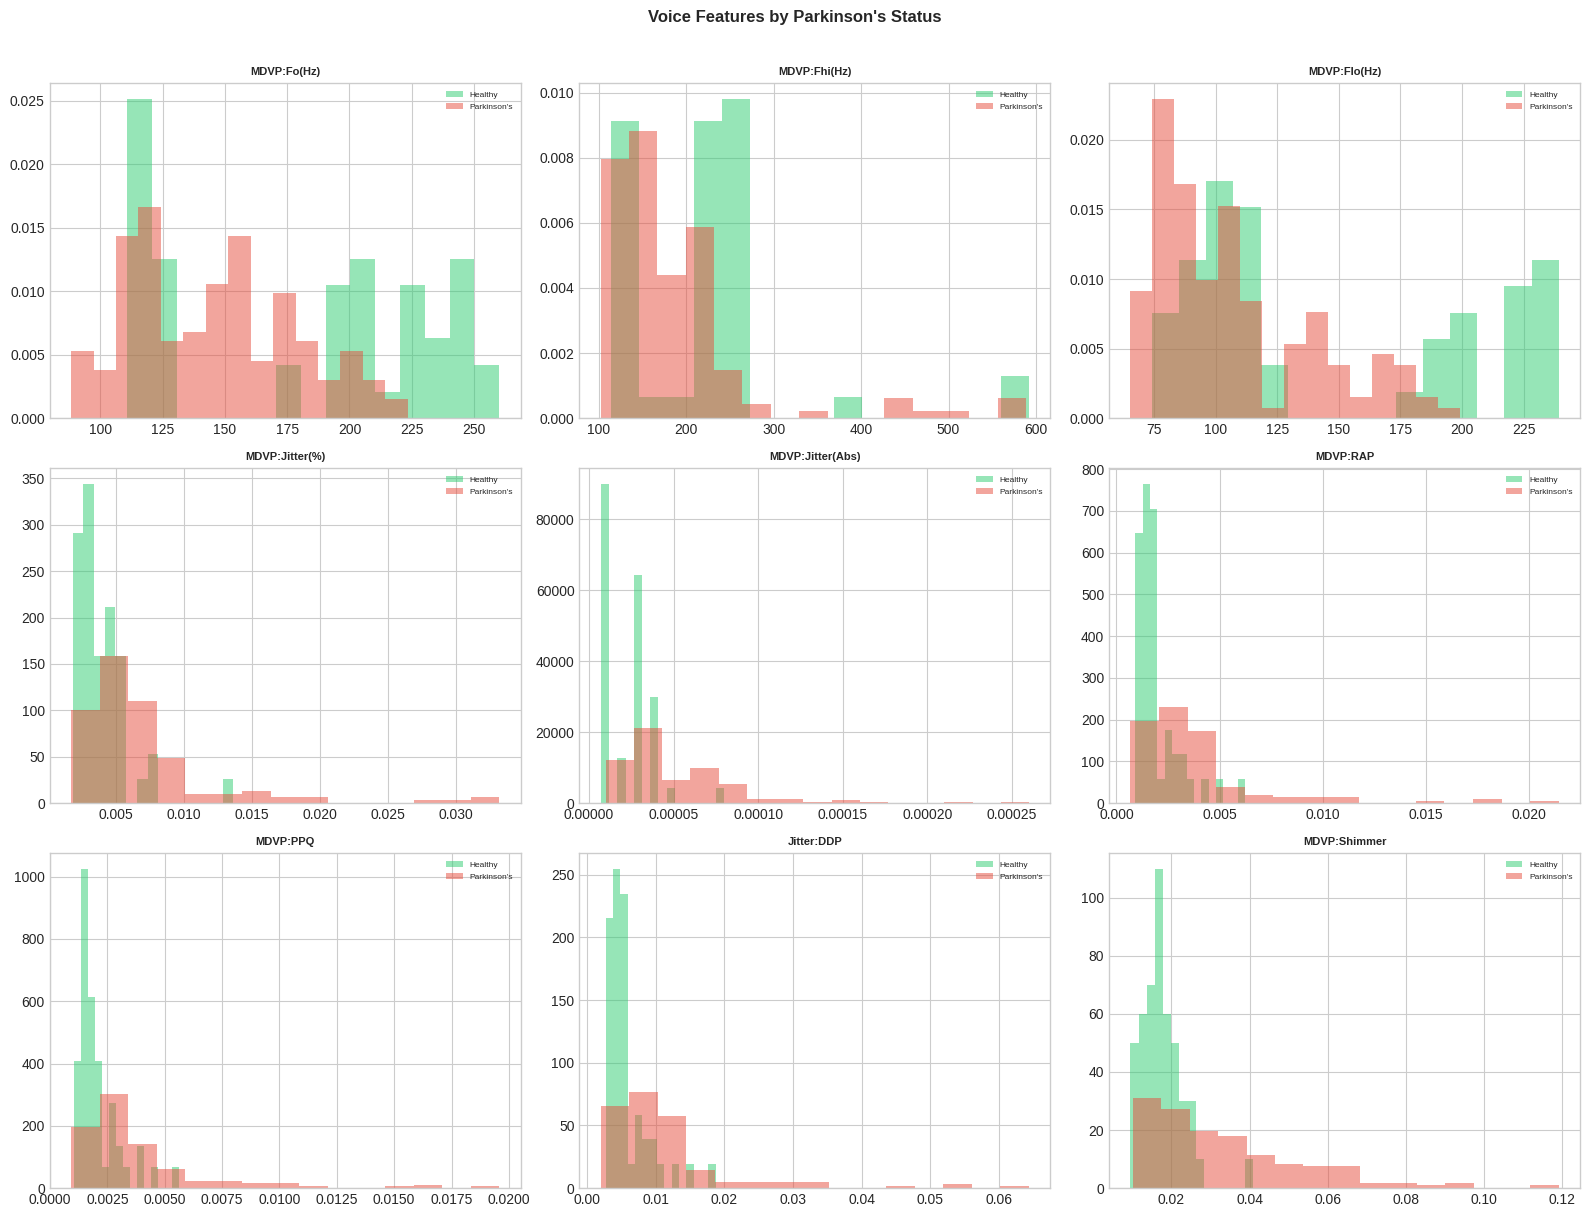

In [5]:
nums=[c for c in df.select_dtypes(include=[np.number]).columns if c!=tc and 'name' not in c.lower()]
print(f"Numeric({len(nums)}): {nums[:10]}")
fig,axes=plt.subplots(3,3,figsize=(16,12));axes=axes.flatten()
for i,col in enumerate(nums[:9]):
    for l,clr,n in zip([0,1],colors,['Healthy',"Parkinson's"]):
        s=df[df[tc]==l][col].dropna()
        if len(s)>0: axes[i].hist(s,bins=15,alpha=0.5,label=n,density=True,color=clr)
    axes[i].set_title(col[:20],fontsize=8,fontweight='bold');axes[i].legend(fontsize=6)
for j in range(i+1,len(axes)):axes[j].set_visible(False)
plt.suptitle("Voice Features by Parkinson's Status",fontweight='bold',y=1.01)
plt.tight_layout();plt.savefig('eda.png',dpi=150);plt.show()

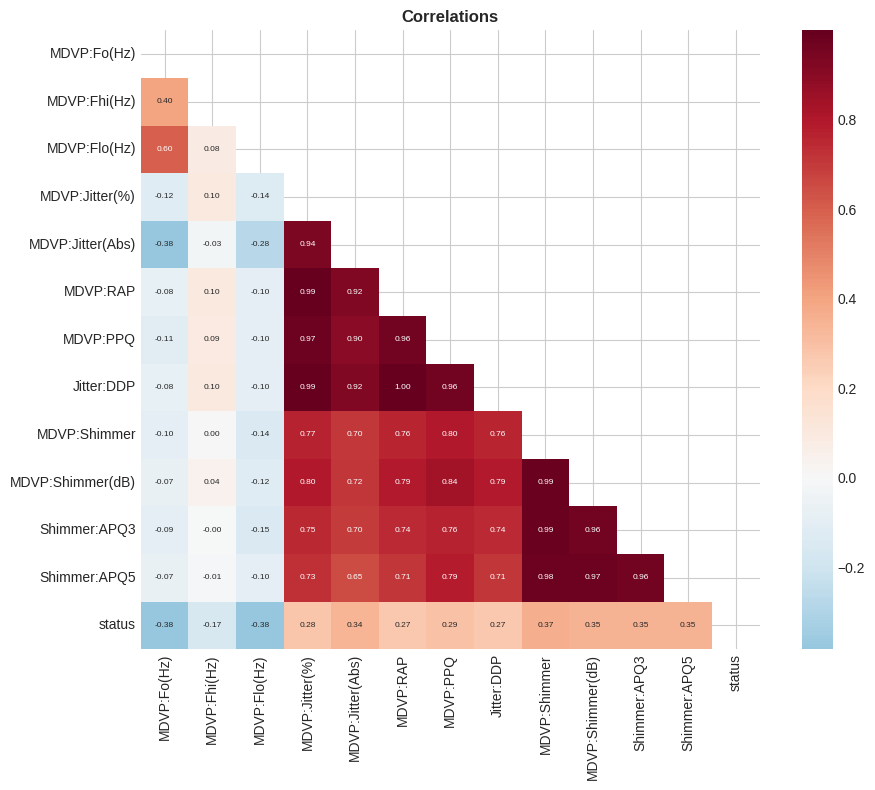

In [6]:
corr=df[nums[:12]+[tc]].corr()
fig,ax=plt.subplots(figsize=(10,8))
sns.heatmap(corr,mask=np.triu(np.ones_like(corr,dtype=bool)),annot=True,fmt='.2f',cmap='RdBu_r',center=0,square=True,ax=ax,annot_kws={'size':6})
ax.set_title('Correlations',fontweight='bold')
plt.tight_layout();plt.savefig('corr.png',dpi=150);plt.show()

## 4. Preprocessing

In [7]:
drop=[c for c in df.columns if c.lower() in ['name','id','unnamed: 0']]
X=df[nums].copy();y=df[tc].values;X=X.fillna(X.median())
print(f"X: {X.shape}")

X: (195, 22)


## 5. Training

In [8]:
try:
    from xgboost import XGBClassifier
except: XGBClassifier=None
try:
    from lightgbm import LGBMClassifier
except: LGBMClassifier=None
models={'LogReg':LogisticRegression(max_iter=2000,random_state=42),'RF':RandomForestClassifier(n_estimators=100,random_state=42,n_jobs=-1)}
if XGBClassifier: models['XGB']=XGBClassifier(n_estimators=100,random_state=42,eval_metric='logloss',use_label_encoder=False,verbosity=0,n_jobs=-1)
if LGBMClassifier: models['LGBM']=LGBMClassifier(n_estimators=100,random_state=42,verbose=-1,n_jobs=-1,force_col_wise=True)
skf=StratifiedKFold(3,shuffle=True,random_state=42);Xa=X.values;results={}
for mn,mod in models.items():
    print(f"\n{'='*50}\n{mn}\n{'='*50}")
    fa,ff,fu=[],[],[];fp=np.zeros(len(y),dtype=int);fpr=np.zeros(len(y));t0=time.time()
    for fi,(ti,vi) in enumerate(skf.split(Xa,y)):
        m2=type(mod)(**mod.get_params());m2.fit(Xa[ti],y[ti]);yp=m2.predict(Xa[vi]);yb=m2.predict_proba(Xa[vi])[:,1]
        fp[vi]=yp;fpr[vi]=yb
        a=accuracy_score(y[vi],yp);f=f1_score(y[vi],yp);u=roc_auc_score(y[vi],yb)
        fa.append(a);ff.append(f);fu.append(u)
        print(f"  Fold{fi+1}: Acc={a:.4f} F1={f:.4f} AUC={u:.4f}")
    el=time.time()-t0
    results[mn]={'acc':np.mean(fa),'f1':np.mean(ff),'auc':np.mean(fu),'time':el,'preds':fp,'proba':fpr}
    print(f"  AVG: Acc={np.mean(fa):.4f} F1={np.mean(ff):.4f} AUC={np.mean(fu):.4f} T={el:.1f}s")


LogReg
  Fold1: Acc=0.9077 F1=0.9400 AUC=0.9311
  Fold2: Acc=0.8308 F1=0.8911 AUC=0.8763
  Fold3: Acc=0.8462 F1=0.9057 AUC=0.8622
  AVG: Acc=0.8615 F1=0.9122 AUC=0.8899 T=0.2s

RF
  Fold1: Acc=0.9538 F1=0.9697 AUC=0.9617
  Fold2: Acc=0.9385 F1=0.9592 AUC=0.9732
  Fold3: Acc=0.8154 F1=0.8868 AUC=0.9356
  AVG: Acc=0.9026 F1=0.9386 AUC=0.9568 T=1.0s

XGB
  Fold1: Acc=0.9538 F1=0.9697 AUC=0.9592
  Fold2: Acc=0.8923 F1=0.9278 AUC=0.9694
  Fold3: Acc=0.8615 F1=0.9126 AUC=0.9439
  AVG: Acc=0.9026 F1=0.9367 AUC=0.9575 T=0.2s

LGBM
  Fold1: Acc=0.9538 F1=0.9697 AUC=0.9643
  Fold2: Acc=0.8769 F1=0.9167 AUC=0.9605
  Fold3: Acc=0.8923 F1=0.9307 AUC=0.9770
  AVG: Acc=0.9077 F1=0.9390 AUC=0.9673 T=0.1s


## 6. Comparison

In [9]:
rows=[{'Model':k,'Acc':f"{v['acc']:.4f}",'F1':f"{v['f1']:.4f}",'AUC':f"{v['auc']:.4f}",'Time':f"{v['time']:.1f}s",'s':v['auc']} for k,v in results.items()]
sdf=pd.DataFrame(rows).sort_values('s',ascending=False);best=sdf.iloc[0]['Model']
print("COMPARISON");print("="*70);print(sdf[['Model','Acc','F1','AUC','Time']].to_string(index=False));print(f"\nBest: {best}")

COMPARISON
 Model    Acc     F1    AUC Time
  LGBM 0.9077 0.9390 0.9673 0.1s
   XGB 0.9026 0.9367 0.9575 0.2s
    RF 0.9026 0.9386 0.9568 1.0s
LogReg 0.8615 0.9122 0.8899 0.2s

Best: LGBM


## 7. Error Analysis

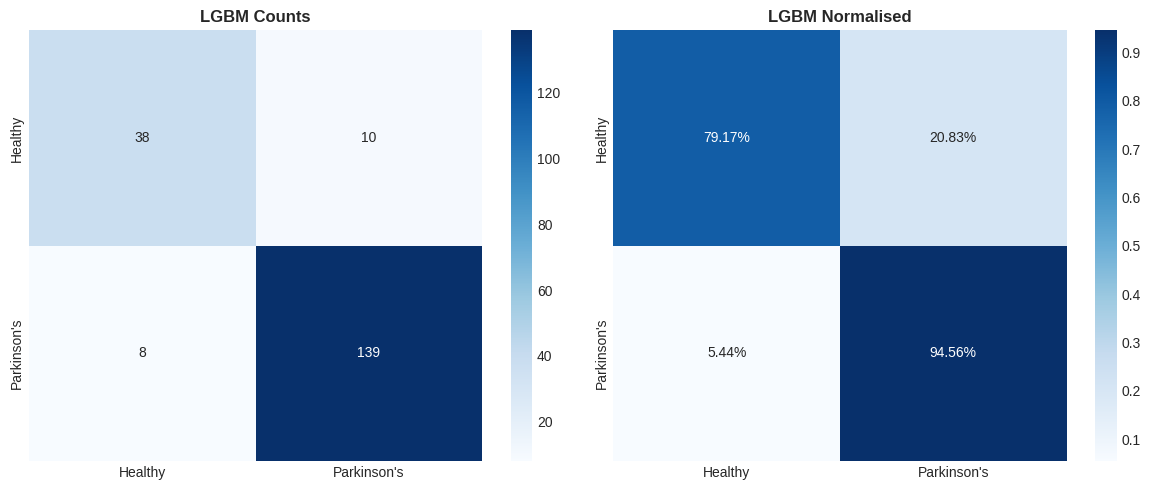

              precision    recall  f1-score   support

     Healthy       0.83      0.79      0.81        48
 Parkinson's       0.93      0.95      0.94       147

    accuracy                           0.91       195
   macro avg       0.88      0.87      0.87       195
weighted avg       0.91      0.91      0.91       195



In [10]:
bp=results[best]['preds'];cm=confusion_matrix(y,bp)
fig,axes=plt.subplots(1,2,figsize=(12,5))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=['Healthy',"Parkinson's"],yticklabels=['Healthy',"Parkinson's"],ax=axes[0])
axes[0].set_title(f'{best} Counts',fontweight='bold')
cm_n=cm.astype(float)/cm.sum(axis=1,keepdims=True)
sns.heatmap(cm_n,annot=True,fmt='.2%',cmap='Blues',xticklabels=['Healthy',"Parkinson's"],yticklabels=['Healthy',"Parkinson's"],ax=axes[1])
axes[1].set_title(f'{best} Normalised',fontweight='bold')
plt.tight_layout();plt.savefig('cm.png',dpi=150);plt.show()
print(classification_report(y,bp,target_names=['Healthy',"Parkinson's"]))

## 8. Feature Importance

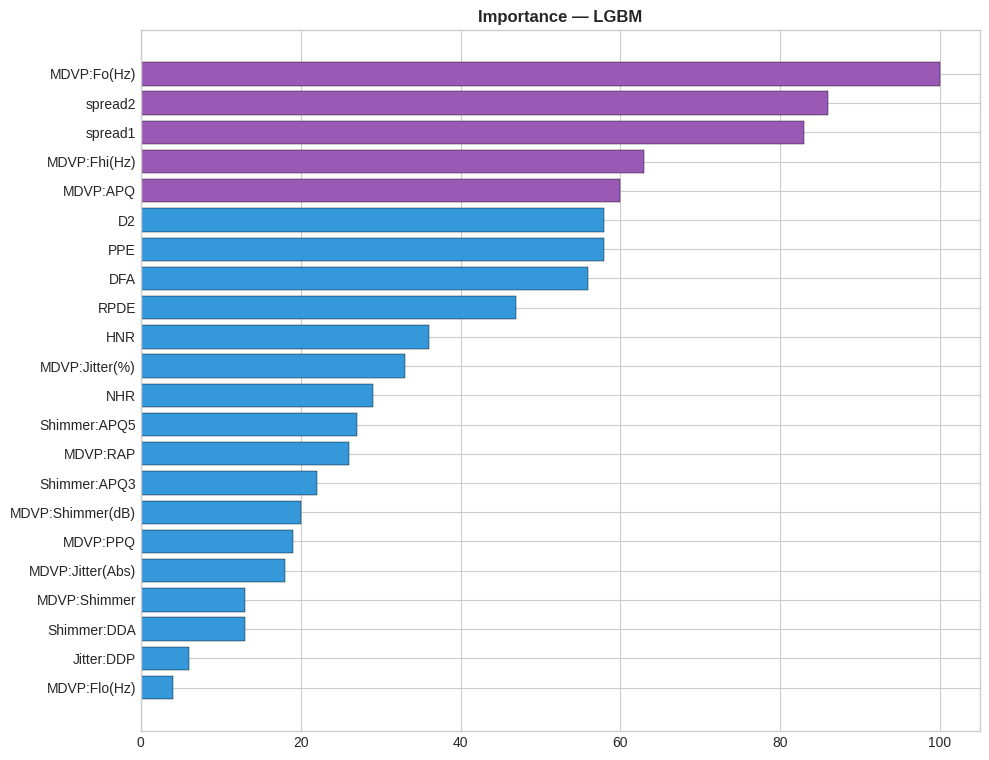

TOP 5
  MDVP:Fo(Hz)               100.0000
  spread2                   86.0000
  spread1                   83.0000
  MDVP:Fhi(Hz)              63.0000
  MDVP:APQ                  60.0000

Voice: Shimmer, jitter, and HNR are key vocal biomarkers for Parkinson's.


In [11]:
tm={k:v for k,v in models.items() if k!='LogReg'}
if tm:
    bt=max(tm,key=lambda m:results[m]['auc']);fm=type(models[bt])(**models[bt].get_params());fm.fit(Xa,y)
    fi=pd.DataFrame({'Feature':X.columns,'Imp':fm.feature_importances_}).sort_values('Imp')
    fig,ax=plt.subplots(figsize=(10,max(5,len(fi)*0.35)))
    ax.barh(fi['Feature'],fi['Imp'],color=['#9b59b6' if v>fi['Imp'].quantile(0.75) else '#3498db' for v in fi['Imp']],edgecolor='black',linewidth=0.3)
    ax.set_title(f'Importance — {bt}',fontweight='bold')
    plt.tight_layout();plt.savefig('imp.png',dpi=150);plt.show()
    print("TOP 5");print("="*40)
    for _,r in fi.tail(5).iloc[::-1].iterrows(): print(f"  {r['Feature']:25s} {r['Imp']:.4f}")
    print("\nVoice: Shimmer, jitter, and HNR are key vocal biomarkers for Parkinson's.")

## 9. Deployment

In [12]:
br=results[best]
print("="*60);print("DEPLOYMENT READINESS");print("="*60)
print(f"  Model: {best}");print(f"  AUC:   {br['auc']:.4f}");print(f"  F1:    {br['f1']:.4f}")
print(f"  Time:  {br['time']:.1f}s");print(f"  Feats: {X.shape[1]}");print(f"  Rows:  {len(y):,}");print("="*60)
checks={'AUC>0.80':br['auc']>0.80,'F1>0.80':br['f1']>0.80,'Time<60s':br['time']<60,'CV':True}
print("\nCHECKLIST");print("-"*40);ap=True
for k,v in checks.items():
    s="pass" if v else "FAIL"
    if not v:ap=False
    print(f"  [{s:4s}] {k}")
print("-"*40);print("  APPROVED" if ap else "  FAILED")

DEPLOYMENT READINESS
  Model: LGBM
  AUC:   0.9673
  F1:    0.9390
  Time:  0.1s
  Feats: 22
  Rows:  195

CHECKLIST
----------------------------------------
  [pass] AUC>0.80
  [pass] F1>0.80
  [pass] Time<60s
  [pass] CV
----------------------------------------
  APPROVED


In [13]:
print("""
PRODUCTION ARCHITECTURE
=======================
1. DATA: Voice recording app/telehealth -> feature extraction -> Fabric
2. MODEL: Real-time at GP consultation, mobile app screening
3. INTEGRATE: GP clinical systems, NDIS assessment, telehealth platforms
4. GOVERN: TGA SaMD, neurologist validation, patient consent
5. MONITOR: Validate vs specialist diagnosis, retrain with new recordings
   Voice-based screening enables low-cost, non-invasive early detection
""")


PRODUCTION ARCHITECTURE
1. DATA: Voice recording app/telehealth -> feature extraction -> Fabric
2. MODEL: Real-time at GP consultation, mobile app screening
3. INTEGRATE: GP clinical systems, NDIS assessment, telehealth platforms
4. GOVERN: TGA SaMD, neurologist validation, patient consent
5. MONITOR: Validate vs specialist diagnosis, retrain with new recordings
   Voice-based screening enables low-cost, non-invasive early detection

